<a href="https://colab.research.google.com/github/devarsh3453/NEW/blob/main/ML_L7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score )
from imblearn.over_sampling import RandomOverSampler, SMOTE
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Column names for Pima Indians Diabetes dataset
columns = [     "Pregnancies",
           "Glucose",     "BloodPressure",     "SkinThickness",
                "Insulin",     "BMI",     "DiabetesPedigreeFunction",
                "Age",     "Outcome" ]
# Load dataset
df = pd.read_csv("/content/master_pima-indians-diabetes.csv",     header=None,     names=columns )
print("First 5 rows:")
display(df.head())
print("\nDataset shape:", df.shape)
print("\nDataset information:")
df.info()

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
print("Class distribution:")
print(df["Outcome"].value_counts())
print("\nClass distribution in percentage:")
print(df["Outcome"].value_counts(normalize=True) * 100)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class distribution in percentage:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x7e1711542ba0>,
 [Text(0, 0, 'No Diabetes'), Text(1, 0, 'Diabetes')])

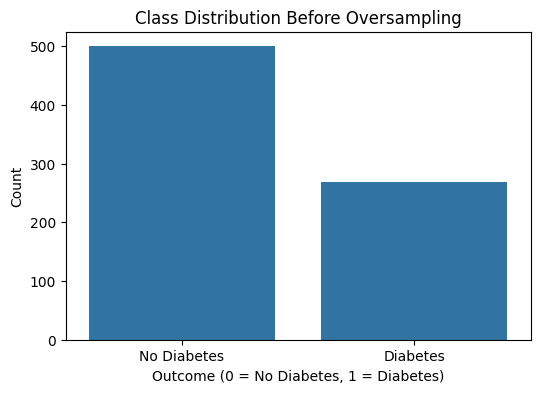

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(
    x="Outcome",
    data=df )
plt.title("Class Distribution Before Oversampling")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])

In [8]:
# Columns where zero may represent missing values
zero_as_missing = [     "Glucose",     "BloodPressure",
                   "SkinThickness",     "Insulin",     "BMI" ]
# Replace zeros with NaN
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [9]:
# Fill missing values using median
for col in zero_as_missing:
  df[col] = df[col].fillna(df[col].median())
print("Missing values after median imputation:")
print(df.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [10]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,     y,
    test_size=0.20,     random_state=42,
    stratify=y
    )
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training set: (614, 8)
Testing set: (154, 8)

Training class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Testing class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Create classifier
lr_original = LogisticRegression(max_iter=1000)
# Train on original imbalanced training data
lr_original.fit(X_train_scaled, y_train)
# Predict on test data
y_pred_original = lr_original.predict(X_test_scaled)
# Predict probabilities for Precision-Recall curve
y_prob_original = lr_original.predict_proba(X_test_scaled)[:, 1]

In [14]:
accuracy_original = accuracy_score(y_test, y_pred_original)
precision_original = precision_score(     y_test, y_pred_original, zero_division=0 )
recall_original = recall_score(     y_test, y_pred_original, zero_division=0 )
f1_original = f1_score(     y_test, y_pred_original, zero_division=0 )
print("Performance Before Oversampling")
print("--------------------------------")
print("Accuracy :", round(accuracy_original, 4))
print("Precision:", round(precision_original, 4))
print("Recall   :", round(recall_original, 4))
print("F1-score :", round(f1_original, 4))
print("\nClassification Report:")
print(classification_report(     y_test,     y_pred_original,     target_names=["No Diabetes", "Diabetes"],     zero_division=0 ))

Performance Before Oversampling
--------------------------------
Accuracy : 0.7078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5455

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



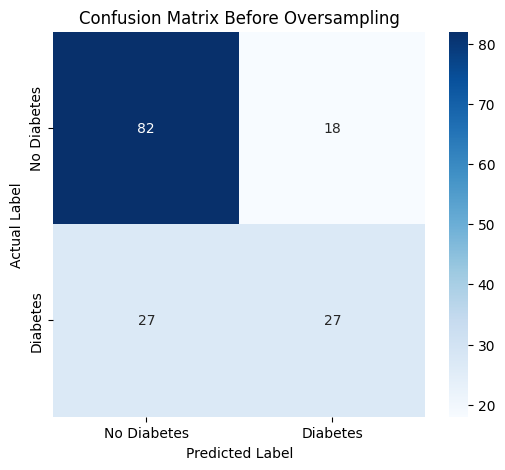

In [17]:
cm_original = confusion_matrix(y_test, y_pred_original)
plt.figure(figsize=(6, 5))

sns.heatmap(     cm_original,     annot=True,     fmt="d",
            cmap="Blues",     xticklabels=["No Diabetes", "Diabetes"],
                 yticklabels=["No Diabetes", "Diabetes"] )
plt.title("Confusion Matrix Before Oversampling")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [18]:
# Create RandomOverSampler
ros = RandomOverSampler(     random_state=42 )
# Apply oversampling ONLY to training data
X_train_ros, y_train_ros = ros.fit_resample(     X_train_scaled,     y_train )
print("Class distribution before Random Oversampling:")
print(y_train.value_counts())
print("\nClass distribution after Random Oversampling:")
print(pd.Series(y_train_ros).value_counts())

Class distribution before Random Oversampling:
Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution after Random Oversampling:
Outcome
0    400
1    400
Name: count, dtype: int64


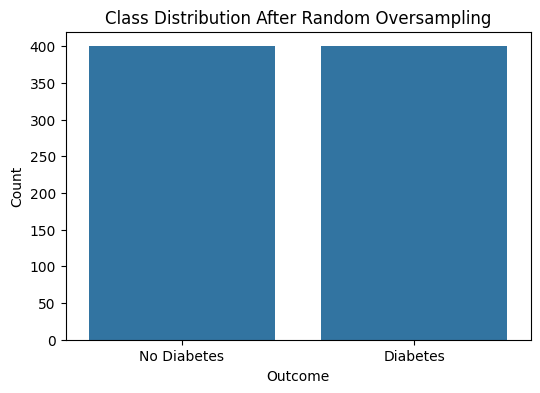

In [20]:
plt.figure(figsize=(6, 4))
sns.countplot(     x=y_train_ros )
plt.title("Class Distribution After Random Oversampling")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

In [21]:
# Create a new Logistic Regression model
lr_ros = LogisticRegression(max_iter=1000)
# Train on oversampled training data
lr_ros.fit(X_train_ros, y_train_ros)
# Predict on the ORIGINAL test set
y_pred_ros = lr_ros.predict(X_test_scaled)
# Predict probabilities
y_prob_ros = lr_ros.predict_proba(X_test_scaled)[:, 1]

In [22]:
accuracy_ros = accuracy_score(y_test, y_pred_ros)
precision_ros = precision_score(     y_test, y_pred_ros, zero_division=0 )
recall_ros = recall_score(     y_test, y_pred_ros, zero_division=0 )
f1_ros = f1_score(     y_test, y_pred_ros, zero_division=0 )

print("Performance After Random Oversampling")
print("--------------------------------------")
print("Accuracy :", round(accuracy_ros, 4))
print("Precision:", round(precision_ros, 4))
print("Recall   :", round(recall_ros, 4))
print("F1-score :", round(f1_ros, 4))
print("\nClassification Report:")
print(classification_report(     y_test,     y_pred_ros,     target_names=["No Diabetes", "Diabetes"],     zero_division=0 ))

Performance After Random Oversampling
--------------------------------------
Accuracy : 0.7338
Precision: 0.6032
Recall   : 0.7037
F1-score : 0.6496

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



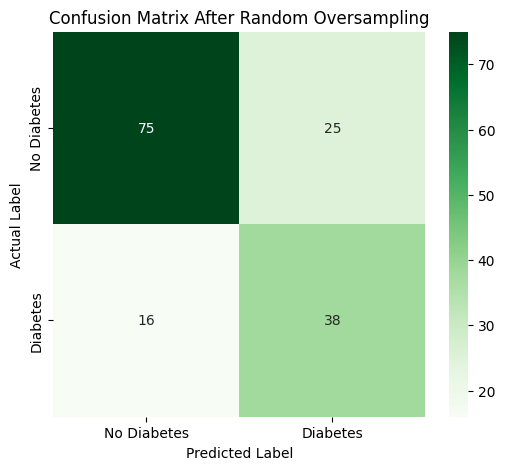

In [23]:
cm_ros = confusion_matrix(y_test, y_pred_ros)
plt.figure(figsize=(6, 5))
sns.heatmap(     cm_ros,     annot=True,     fmt="d",     cmap="Greens",     xticklabels=["No Diabetes", "Diabetes"],     yticklabels=["No Diabetes", "Diabetes"] )
plt.title("Confusion Matrix After Random Oversampling")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [24]:
# Create SMOTE
smote = SMOTE(     random_state=42 )
# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(     X_train_scaled,     y_train )
print("Class distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Class distribution before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

Class distribution after SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


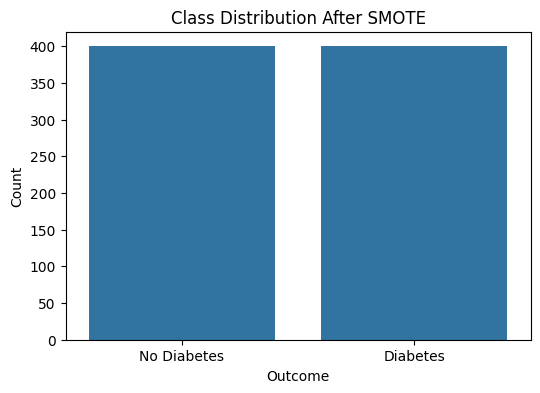

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(     x=y_train_smote )
plt.title("Class Distribution After SMOTE")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

In [26]:
# Create a new Logistic Regression model
lr_smote = LogisticRegression(max_iter=1000)
# Train on SMOTE-balanced data
lr_smote.fit(X_train_smote, y_train_smote)
# Predict on original test data
y_pred_smote = lr_smote.predict(X_test_scaled)
# Predict probabilities
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

In [27]:
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(     y_test, y_pred_smote, zero_division=0 )
recall_smote = recall_score(     y_test, y_pred_smote, zero_division=0 )
f1_smote = f1_score(     y_test, y_pred_smote, zero_division=0 )
print("Performance After SMOTE")
print("-----------------------")
print("Accuracy :", round(accuracy_smote, 4))
print("Precision:", round(precision_smote, 4))
print("Recall   :", round(recall_smote, 4))
print("F1-score :", round(f1_smote, 4))
print("\nClassification Report:")
print(classification_report(     y_test,     y_pred_smote,     target_names=["No Diabetes", "Diabetes"],     zero_division=0 ))

Performance After SMOTE
-----------------------
Accuracy : 0.7143
Precision: 0.5806
Recall   : 0.6667
F1-score : 0.6207

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.80      0.74      0.77       100
    Diabetes       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



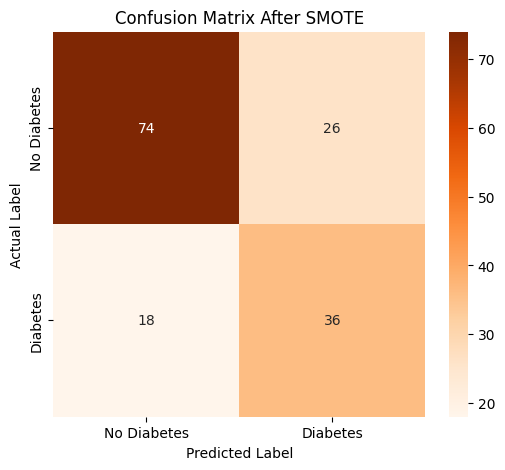

In [29]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
plt.figure(figsize=(6, 5))
sns.heatmap(     cm_smote,     annot=True,     fmt="d",     cmap="Oranges",     xticklabels=["No Diabetes", "Diabetes"],     yticklabels=["No Diabetes", "Diabetes"] )
plt.title("Confusion Matrix After SMOTE")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [30]:
comparison = pd.DataFrame({     "Method": [
         "Original Imbalanced",         "Random Oversampling",
         "SMOTE"     ],
                                "Accuracy": [
                    accuracy_original,         accuracy_ros,
                    accuracy_smote     ],
                                "Precision": [         precision_original,
                                              precision_ros,         precision_smote     ],
                                   "Recall": [         recall_original,
                                              recall_ros,         recall_smote     ],
                                  "F1-score": [         f1_original,         f1_ros,
                                               f1_smote     ] })
print("Performance Comparison:")
display(comparison.round(4))

Performance Comparison:


,Method,Accuracy,Precision,Recall,F1-score
0,Original Imbalanced,0.7078,0.6000,0.5000,0.5455
1,Random Oversampling,0.7338,0.6032,0.7037,0.6496
2,SMOTE,0.7143,0.5806,0.6667,0.6207


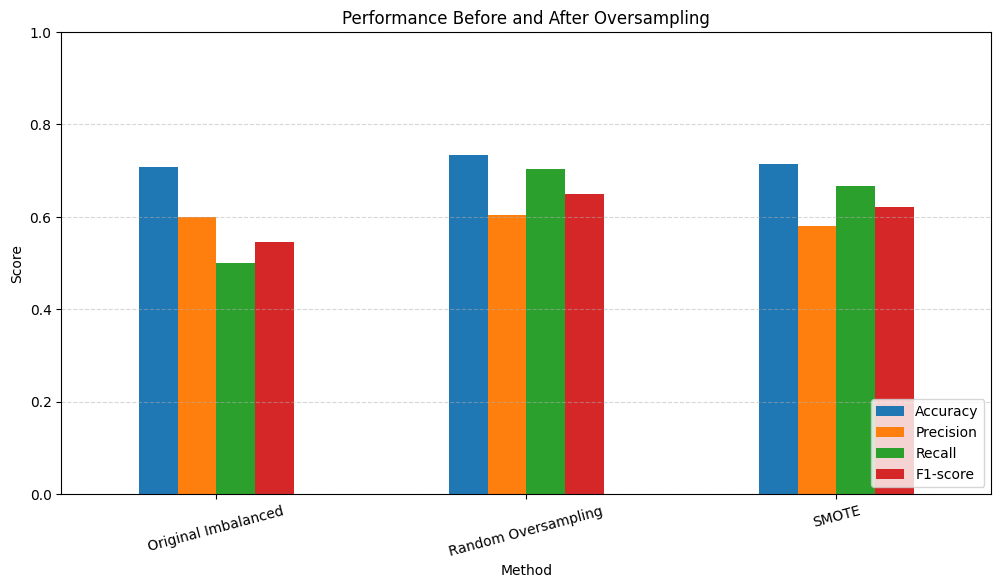

In [34]:
comparison_plot = comparison.set_index("Method")
comparison_plot.plot(     kind="bar",     figsize=(12, 6),     ylim=(0, 1),     rot=15 )
plt.title("Performance Before and After Oversampling")
plt.ylabel("Score")
plt.xlabel("Method")
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

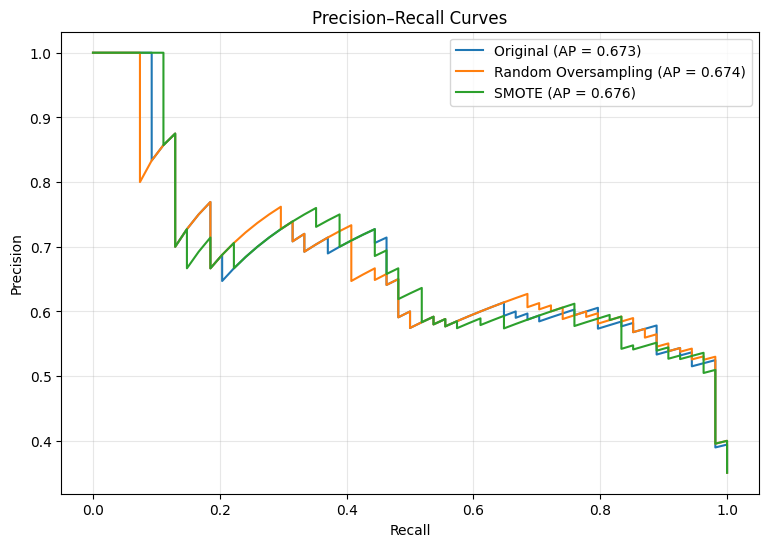

In [36]:
# Calculate Precision-Recall values
precision_orig_curve, recall_orig_curve, _ = precision_recall_curve(     y_test, y_prob_original )
precision_ros_curve, recall_ros_curve, _ = precision_recall_curve(     y_test, y_prob_ros )
precision_smote_curve, recall_smote_curve, _ = precision_recall_curve(     y_test, y_prob_smote )

# Average Precision scores
ap_original = average_precision_score(y_test, y_prob_original)
ap_ros = average_precision_score(y_test, y_prob_ros)
ap_smote = average_precision_score(y_test, y_prob_smote)


plt.figure(figsize=(9, 6))
plt.plot(     recall_orig_curve,     precision_orig_curve,
         label=f"Original (AP = {ap_original:.3f})" )
plt.plot(     recall_ros_curve,     precision_ros_curve,     label=f"Random Oversampling (AP = {ap_ros:.3f})" )
plt.plot(     recall_smote_curve,     precision_smote_curve,     label=f"SMOTE (AP = {ap_smote:.3f})" )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

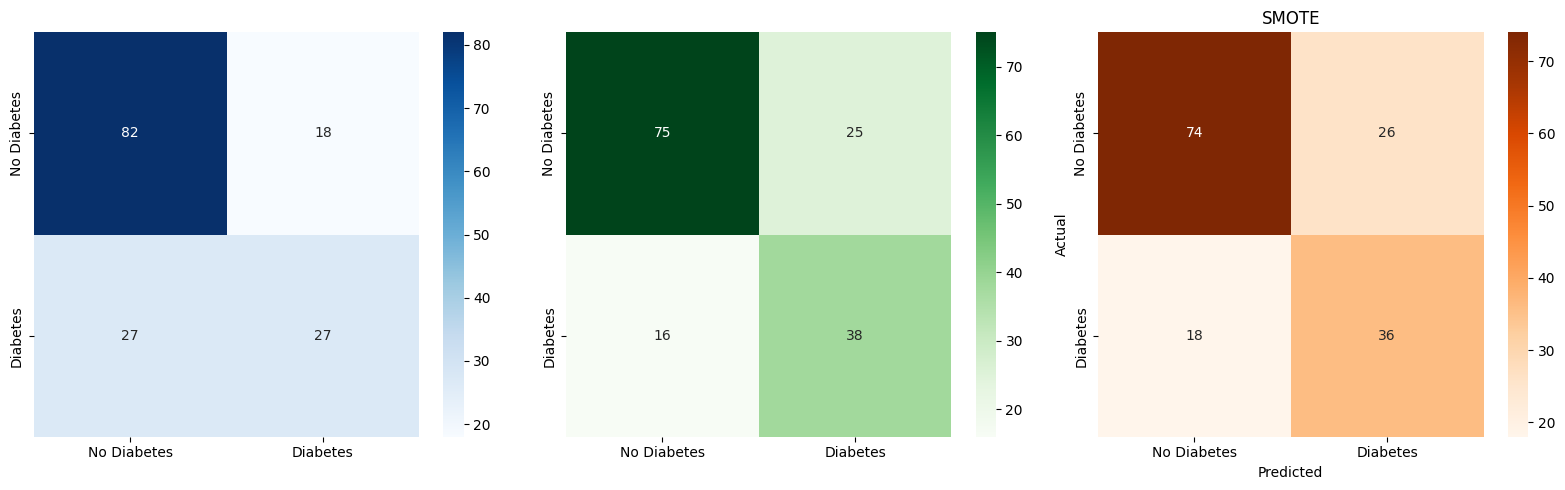

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
confusion_matrices = [     (cm_original, "Original Imbalanced", "Blues"),
 (cm_ros, "Random Oversampling", "Greens"),
                           (cm_smote, "SMOTE", "Oranges") ]
for ax, (cm, title, cmap) in zip(axes, confusion_matrices):
  sns.heatmap(         cm,         annot=True,         fmt="d",         cmap=cmap,         ax=ax,
              xticklabels=["No Diabetes", "Diabetes"],         yticklabels=["No Diabetes", "Diabetes"]     )
ax.set_title(title)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()